# Exercise

## 1. Simulate and forecast a random walk

1. Generate a random walk of 500 timesteps. Feel free to
choose an initial value different from 0. Also, make sure
you change the seed by passing a different integer to
np.random.seed().
2. Plot your simulated random walk.
3. Test for stationarity.
4. Apply a first-order difference.
5. Test for stationarity.
6. Split your simulated random walk into a train set
containing the first 400 timesteps. The remaining 100
timesteps will be your test set.
7. Apply different naive forecasting methods and measure
the MSE. Which method yields the lowest MSE?
8. Plot your forecasts.
9. Forecast the next timestep over the test set and measure
the MSE. Did it decrease?
10. Plot your forecasts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Generate a random walk of 500

np.random.seed(40)
steps = np.random.standard_normal(500)
steps[0] = 10
random_walk = np.cumsum(steps)

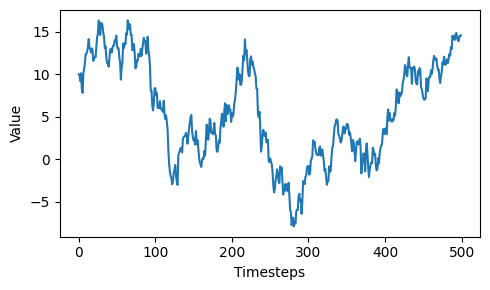

In [3]:
# 2. Plot your simulated random walk

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(random_walk)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
plt.tight_layout()

In [4]:
# 3. Test for stationarity

from statsmodels.tsa.stattools import adfuller

adf = adfuller(random_walk)
print(f"ADF Statistic: {adf[0]}")
print(f"p-value: {adf[1]}")

ADF Statistic: -1.5913356419504
p-value: 0.48794444566321105


As p-value is not low enough to reject the null hypothesis of ADF test, we cannot reject the hypothesis that unit root is present in the series. And hence, we can say the tested series is not stationary.

In [5]:
# 4. Apply a first-order difference.

diff_random_walk = np.diff(random_walk, n=1)

In [6]:
# 5. Test for stationarity.

adf = adfuller(diff_random_walk)
print(f"ADF Statistic: {adf[0]}")
print(f"p-value: {adf[1]}")

ADF Statistic: -21.97352511752583
p-value: 0.0


As p-value is almost zero, we can reject the hypothesis that unit root is present in the series. And hence, we can say the tested series is stationary.

In [7]:
# 6. Split your simulated random walk...

import pandas as pd

df = pd.DataFrame({"values": random_walk})

train = df[:400]
test = df[400:]

In [8]:
# 7. Apply different naive forecasting methods..

# Predicting the mean
mean = train.values.mean().item()
test["pred_mean"] = mean

# Predicting by the last known value
last_value = train.iloc[-1].values.item()
test["pred_last"] = last_value

# Predict with drift
deltaX = 400 - 0
deltaY = last_value - 10

drift = deltaY / deltaX
x_vals = np.arange(400, 500, 1)
pred_drift = drift * x_vals + 10
test.loc[:, "pred_drift"] = pred_drift

test.head()

,values,pred_mean,pred_last,pred_drift
400,3.535928,4.571965,2.960159,2.960159
401,3.627021,4.571965,2.960159,2.942559
402,2.928230,4.571965,2.960159,2.924960
403,4.910073,4.571965,2.960159,2.907360
404,5.861157,4.571965,2.960159,2.889760


In [9]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test["values"], test["pred_mean"])
mse_last = mean_squared_error(test["values"], test["pred_last"])
mse_drift = mean_squared_error(test["values"], test["pred_drift"])

print(mse_mean, mse_last, mse_drift)

34.90129556985135 54.07514083616252 69.38118694822901


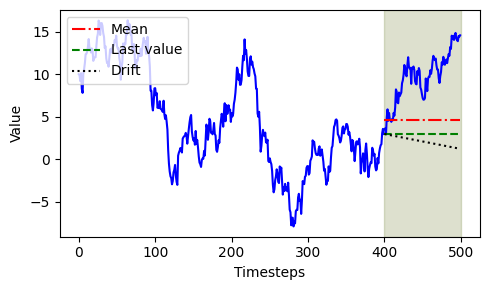

In [10]:
# 8. Plot your forecasts.

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(train["values"], "b-")
ax.plot(test["values"], "b-")
ax.plot(test["pred_mean"], "r-.", label="Mean")
ax.plot(test["pred_last"], "g--", label="Last value")
ax.plot(test["pred_drift"], "k:", label="Drift")

ax.axvspan(400, 500, color="#55680C15", alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()

In [11]:
# 9. Forecast the next timestep over the test set and measure the MSE

df_shift = df.shift(periods=1)

mse_one_step = mean_squared_error(test["values"], df_shift[400:])
mse_one_step

0.670898152293387

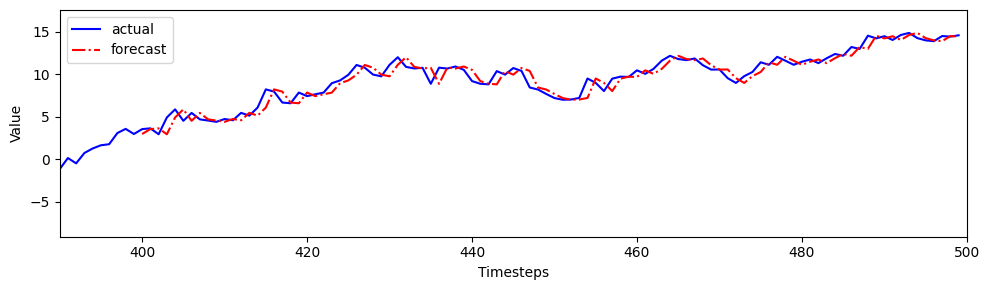

In [12]:
# 10. Plot your forecasts

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(df, "b-", label="actual")
ax.plot(df_shift[400:], "r-.", label="forecast")

ax.legend(loc=2)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.xlim(390, 500)
plt.tight_layout()